In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# LabOne Q imports
from laboneq.simple import (
    Session,
    Experiment,
    ExperimentSignal,
    pulse_library,
    AcquisitionType,
    RepetitionMode,
    SectionAlignment,
    OutputSimulator,
)
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.simple import Calibration, SignalCalibration, Oscillator, ModulationType
from qubit import VirtualQubit

In [2]:
# Device setup

def make_session(): 
    """Create a LabOne Q device setup and session in emulation mode.

    Returns:
        (session, device_setup, q0) — the session, device descriptor, and qubit 0 object.
    """
    device_setup, qubits = generate_device_setup_qubits(
        number_qubits=1,
        pqsc=[{"serial": "DEV10001"}],
        hdawg=[{"serial": "DEV8001", "zsync": 0, "number_of_channels": 8, "options": None}],
        shfqc=[
            {
                "serial": "DEV12001",
                "zsync": 1,
                "number_of_channels": 6,
                "readout_multiplex": 6,
                "options": None,
            }
        ],
        include_flux_lines=True,
        server_host="localhost",
        setup_name="hackathon_singleQubit",
    )
    session = Session(device_setup)
    session.connect(do_emulation=True)
    q0 = qubits[0]
    return session, device_setup, q0

In [3]:
# Waveform extraction
def get_drive_waveform(
    session: Session,
    device_setup,
    q0,
    exp: Experiment,
    pulse_length: float,
):
    """Compile an experiment and extract the drive waveform envelope.

    Args:
        session:      Active LabOne Q session.
        device_setup: Device descriptor.
        q0:           Qubit object (LabOne Q).
        exp:          Experiment to compile.
        pulse_length: Duration [s] of the time axis to return.

    Returns:
        (t, wave) — time array starting at 0, complex envelope array.
    """
    compiled = session.compile(exp)
    drive_port = device_setup.logical_signal_by_uid(q0.uid + "/drive").physical_channel
    sim = OutputSimulator(compiled)
    snippet = sim.get_snippet(drive_port, start=0, output_length=pulse_length)
    t = snippet.time - snippet.time[0]   # ensure t[0] == 0
    return t, snippet.wave

In [4]:
# Experiment builders

def make_spec_experiment(q0, drive_freq: float, pulse_length: float = 2e-6,  amplitude=0.5):
    """Square-pulse spectroscopy experiment at a single drive frequency.

    Args:
        q0:          LabOne Q qubit object (for signal map).
        drive_freq:  Drive frequency [Hz] to set on the signal calibration.
        pulse_length: Duration of the square drive pulse [s].

    Returns:
        Configured (but not compiled) LabOne Q Experiment.
    """

    spec_pulse = pulse_library.const(uid="spec_pulse", length=pulse_length, amplitude=amplitude)

    exp = Experiment(
        uid="Spectroscopy",
        signals=[ExperimentSignal("drive")],
    )

    # Set calibration so the drive signal oscillates at drive_freq
    cal = Calibration()
    cal["drive"] = SignalCalibration(
        oscillator=Oscillator(
            frequency=drive_freq,
            modulation_type=ModulationType.HARDWARE,
        )
    )
    exp.set_calibration(cal)

    with exp.acquire_loop_rt(
        uid="shots",
        count=1,
        acquisition_type=AcquisitionType.SPECTROSCOPY,
        repetition_mode=RepetitionMode.CONSTANT,
        repetition_time=pulse_length + 500e-9,
    ):
        with exp.section(uid="drive_section"):
            exp.play(signal="drive", pulse=spec_pulse)

    exp.set_signal_map({"drive": q0.signals["drive"]})
    return exp

In [5]:
# Experiment builders

def make_rabi_experiment(q0, drive_freq: float, pulse_length: float = 2e-6,  amplitude=0.5):
    """gaussian-pulse spectroscopy experiment at a single drive frequency.

    Args:
        q0:          LabOne Q qubit object (for signal map).
        drive_freq:  Drive frequency [Hz] to set on the signal calibration.
        pulse_length: Duration of the square drive pulse [s].
        amplitude: 

    Returns:
        Configured (but not compiled) LabOne Q Experiment.
    """

    spec_pulse = pulse_library.gaussian(uid="gauss", length=pulse_length, amplitude=amplitude)

    exp = Experiment(
        uid="GaussianDrive",
        signals=[ExperimentSignal("drive")],
    )

    # Set calibration so the drive signal oscillates at drive_freq
    cal = Calibration()
    cal["drive"] = SignalCalibration(
        oscillator=Oscillator(
            frequency=drive_freq,
            modulation_type=ModulationType.HARDWARE,
        )
    )
    exp.set_calibration(cal)

    with exp.acquire_loop_rt(
        uid="shots",
        count=1,
        acquisition_type=AcquisitionType.SPECTROSCOPY,
        repetition_mode=RepetitionMode.CONSTANT,
        repetition_time=pulse_length + 500e-9,
    ):
        with exp.section(uid="drive_section"):
            exp.play(signal="drive", pulse=spec_pulse)

    exp.set_signal_map({"drive": q0.signals["drive"]})
    return exp

In [ ]:
def lorentzian(f, f0, width, amplitude, offset):
    return offset + amplitude / (1 + ((f - f0) / (width / 2)) ** 2)


def fit_lorentzian(freqs: np.ndarray, P1: np.ndarray) -> float:
    """Fit a Lorentzian peak to spectroscopy data and return the centre frequency."""
    f0_guess = freqs[np.argmax(P1)]
    width_guess = (freqs[-1] - freqs[0]) / 10
    amp_guess = np.max(P1) - np.min(P1)
    offset_guess = np.min(P1)
    popt, pcov = curve_fit(
        lorentzian, freqs, P1,
        p0=[f0_guess, width_guess, amp_guess, offset_guess],
        maxfev=10000,
    )
    return popt[0], float(np.sqrt(pcov[0, 0]))

def voigt(f, f0, sigma, gamma, amp, offset):
    """Voigt profile = Gaussian (instrument) (x) Lorentzian (qubit line).
 
    Args:
        f0:    centre frequency
        sigma: Gaussian std (instrument response, set by pulse spectrum)
        gamma: Lorentzian HWHM (intrinsic qubit linewidth ~ 1/(2 pi T2))
        amp:   peak amplitude (the value at f=f0 minus offset, BEFORE
               normalisation -- we multiply scipy's normalised profile
               by amp / V(0; sigma, gamma) so this stays a true peak height)
        offset: baseline
    """
    profile = voigt_profile(f - f0, sigma, gamma)
    peak = voigt_profile(0.0, sigma, gamma)
    return offset + amp * profile / peak
    
def fit_voigt(freqs, P1, sigma_init=None):
    """Voigt fit. sigma_init: initial Gaussian sigma in Hz (~pulse-spectral width)."""
    f0_g = freqs[np.argmax(P1)]
    span = freqs[-1] - freqs[0]
    if sigma_init is None:
        sigma_init = span / 100
    p0 = [f0_g, sigma_init, sigma_init * 0.5,
          np.max(P1) - np.min(P1), np.min(P1)]
    bounds = (
        [freqs[0],  span * 1e-5, 0.0,  0,    -0.1],
        [freqs[-1], span * 0.5,  span, 1.5,   1.0],
    )

    popt, pcov = curve_fit(voigt, freqs, P1, p0=p0, bounds=bounds,
                           maxfev=20000)
    f0, f0_err = popt[0], float(np.sqrt(pcov[0, 0]))
    rms = float(np.sqrt(np.mean((P1 - voigt(freqs, *popt)) ** 2)))  # unpack popt; ** not *
    return f0, f0_err

def sinusoid(x, A, omega, phi, offset):
    return offset + A * np.sin(omega * x + phi)


def fit_sinusoid(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float, float]:
    """Fit a sinusoid and return (A, omega, phi, offset)."""
    A_guess = (np.max(y) - np.min(y)) / 2
    offset_guess = np.mean(y)
    # Rough frequency estimate via FFT
    fft = np.abs(np.fft.rfft(y - offset_guess))
    freqs = np.fft.rfftfreq(len(x), d=(x[1] - x[0]))
    omega_guess = 2 * np.pi * freqs[np.argmax(fft[1:]) + 1]
    try:
        popt, _ = curve_fit(
            sinusoid, x, y,
            p0=[A_guess, omega_guess, 0, offset_guess],
            maxfev=10000,
        )
        return popt
    except RuntimeError:
        return A_guess, omega_guess, 0.0, offset_guess


def exponential_decay(t, A, T1, offset):
    return offset + A * np.exp(-t / T1)


def fit_T1(delays: np.ndarray, P1: np.ndarray) -> float:
    """Fit exponential decay to T1 data, return T1 [s]."""
    try:
        popt, _ = curve_fit(
            exponential_decay, delays, P1,
            p0=[np.max(P1), 30e-6, np.min(P1)],
            maxfev=10000,
        )
        return popt[1]
    except RuntimeError:
        print("  [warn] T1 fit failed, returning rough estimate")
        return delays[np.argmax(P1 < 0.5 * np.max(P1))]
    
def ramsey_decay(t, A, T2, omega, phi, offset):
    """Exponentially decaying sinusoid for Ramsey fringe fitting.
    
    P(t) = offset + A * exp(-t / T2) * sin(omega * t + phi)
    
    Args:
        t:      Free-precession delay [s].
        A:      Fringe amplitude.
        T2:     Dephasing time [s]  ← what we want to extract.
        omega:  Angular fringe frequency [rad/s] = 2π * detuning_measured.
        phi:    Phase offset [rad].
        offset: Baseline (~0.5 for a perfect π/2 pulse).
    """
    return offset + A * np.exp(-t / T2) * np.sin(omega * t + phi)


def fit_ramsey(delays, P1):
    """Fit a decaying sinusoid to Ramsey data.

    Returns:
        f_fringe : fringe oscillation frequency [Hz]
        T2       : fitted dephasing time [s]
        T2_err   : 1-sigma uncertainty on T2 [s]
        popt     : full parameter array [A, T2, omega, phi, offset]
        pcov     : covariance matrix
    """
    # Seed omega from FFT of the mean-subtracted signal
    A_guess      = (np.max(P1) - np.min(P1)) / 2
    offset_guess = np.mean(P1)
    fft_mag      = np.abs(np.fft.rfft(P1 - offset_guess))
    fft_freq     = np.fft.rfftfreq(len(delays), d=float(delays[1] - delays[0]))
    omega_guess  = 2 * np.pi * fft_freq[np.argmax(fft_mag[1:]) + 1]

    # T2 seed: use the full delay span / 3 as a conservative guess
    T2_guess = float(delays[-1]) / 3

    p0 = [A_guess, T2_guess, omega_guess, 0.0, offset_guess]

    bounds = (
        [0,       1e-8,  omega_guess * 0.5, -np.pi, 0.0],
        [1.0,     1e-2,  omega_guess * 2.0,  np.pi, 1.0],
    )

    try:
        popt, pcov = curve_fit(
            ramsey_decay, delays, P1,
            p0=p0, bounds=bounds, maxfev=20000,
        )
        A, T2, omega_fit, phi, offset = popt
        T2_err   = float(np.sqrt(pcov[1, 1]))
        f_fringe = omega_fit / (2 * np.pi)
        return f_fringe, T2, T2_err, popt, pcov
    except RuntimeError:
        print("  [warn] Ramsey fit failed, returning FFT estimate")
        return omega_guess / (2 * np.pi), T2_guess, np.nan, p0, None


In [ ]:
def qubit_spectroscopy(
    virtual_qubit: VirtualQubit,
    session: Session,
    device_setup,
    q0_loneq,
    freq_start: float = 5.0e9,
    freq_stop: float = 6.2e9,
    n_points: int = 101,
    shots: int = 2000,
    pulse_length: float = 2e-6,
    fit_type: str = "voigt"
):
    """Sweep drive frequency and measure excited-state population.

    Args:
        virtual_qubit: The VirtualQubit to drive and measure.
        session:       LabOne Q session.
        device_setup:  Device descriptor.
        q0_loneq:      LabOne Q qubit object.
        freq_start:    Sweep start frequency [Hz].
        freq_stop:     Sweep stop frequency [Hz].
        n_points:      Number of frequency points.
        shots:         Measurement shots per frequency.
        pulse_length:  Square pulse duration [s].

    Returns:
        (freqs, P1) — frequency array and excited-state probabilities.
    """
    freqs = np.linspace(freq_start, freq_stop, n_points)
    P1 = []

    print(f"  Spectroscopy: sweeping {n_points} frequencies from {freq_start/1e9:.2f} to {freq_stop/1e9:.2f} GHz")

    for f in freqs:
        if fit_type == "voigt":
            exp = make_rabi_experiment(q0_loneq, drive_freq=f, pulse_length=pulse_length)
        elif fit_type == "lorentzian":
            exp = make_spec_experiment(q0_loneq, drive_freq=f, pulse_length=pulse_length)
       
        t, wave = get_drive_waveform(session, device_setup, q0_loneq, exp, pulse_length)

        virtual_qubit.reset()
        virtual_qubit.evolve(t, wave, drive_freq=f)
        bits = virtual_qubit.measure(shots=shots)
        P1.append(bits.mean())

    if fit_type == "voigt":
        f_q, f_err = fit_voigt(freqs, P1)
    elif fit_type == "lorentzian":
        f_q, f_err = fit_lorentzian(freqs, P1)
        
    print(f"  → f_q (spectroscopy) = {f_q / 1e9:.5f} GHz")

    return freqs, np.array(P1), f_q, f_err

In [ ]:
def amplitude_rabi_ramsey(
    virtual_qubit: VirtualQubit,
    session: Session,
    device_setup,
    q0_loneq,
    drive_freq: float,
    amp_start: float = 0.01,
    amp_stop: float = 4.0,
    n_points: int = 51,
    shots: int = 2000,
    pulse_length: float = 100e-9,
):
    """Sweep pulse amplitude and fit Rabi oscillations to find π and π/2 amplitudes.

    Args:
        virtual_qubit: The VirtualQubit to drive and measure.
        session:       LabOne Q session.
        device_setup:  Device descriptor.
        q0_loneq:      LabOne Q qubit object.
        drive_freq:    Resonance frequency to drive at [Hz].
        amp_start:     Sweep start amplitude.
        amp_stop:      Sweep stop amplitude.
        n_points:      Number of amplitude points.
        shots:         Measurement shots per amplitude.
        pulse_length:  Gaussian pulse duration [s].

    Returns:
        (amp_pi, amp_pi2) — π and π/2 pulse amplitudes.
    """
    amps = np.linspace(amp_start, amp_stop, n_points)
    P1 = []

    print(f"  Amplitude Rabi: sweeping {n_points} amplitudes")

    for amp in amps:
        exp = make_rabi_experiment(q0_loneq, amplitude=amp, pulse_length=pulse_length, drive_freq=drive_freq)
        t, wave = get_drive_waveform(session, device_setup, q0_loneq, exp, pulse_length)

        virtual_qubit.reset()
        virtual_qubit.evolve(t, wave, drive_freq=drive_freq)
        bits = virtual_qubit.measure(shots=shots)
        P1.append(bits.mean())

    P1 = np.array(P1)
    A, omega, phi, offset = fit_sinusoid(amps, P1)

    # π pulse: first maximum of the sinusoid
    amp_pi = (np.pi / 2 - phi) / omega

    amp_pi2 = amp_pi/2


    return amps, P1, float(amp_pi), float(amp_pi2)


In [ ]:
def measure_T1(
    virtual_qubit: VirtualQubit,
    session: Session,
    device_setup,
    q0_loneq,
    drive_freq: float,
    amp_pi: float,
    evolve_start: float = 0.5e-6,
    evolve_stop: float = 80e-6,
    n_points: int = 40,
    shots: int = 2000,
    pulse_length: float = 100e-9,
):
    """Apply π pulse, wait variable delay, measure — fit exponential to get T1.

    Args:
        virtual_qubit: The VirtualQubit.
        session:       LabOne Q session.
        device_setup:  Device descriptor.
        q0_loneq:      LabOne Q qubit object.
        drive_freq:    Qubit resonance frequency [Hz].
        amp_pi:        Calibrated π-pulse amplitude.
        evolve_start:   Shortest wait delay [s].
        evolve_stop:    Longest wait delay [s].
        n_points:      Number of delay points.
        shots:         Measurement shots per delay.
        pulse_length:  Duration of the π pulse [s].

    Returns:
        Fitted T1 relaxation time [s].
    """
    evolve_times = np.linspace(evolve_start, evolve_stop, n_points)
    P1 = []

    print(f"  T1 measurement: {n_points} delay points up to {evolve_stop*1e6:.0f} µs")

    # Build the π-pulse waveform once (reuse across delays)
    exp_pi = make_rabi_experiment(q0_loneq, amplitude=amp_pi, pulse_length=pulse_length, drive_freq= drive_freq)
    t_pi, wave_pi = get_drive_waveform(session, device_setup, q0_loneq, exp_pi, pulse_length)

    for evolve_time in evolve_times:
        virtual_qubit.reset()
        virtual_qubit.evolve(t_pi, wave_pi, drive_freq=drive_freq)  # π pulse → |1⟩
        virtual_qubit.wait(drive_freq, evolve_time) 
        bits = virtual_qubit.measure(shots=shots)
        P1.append(bits.mean())

    T1_fit = fit_T1(evolve_times, np.array(P1))
    return evolve_times, P1, T1_fit, P1


In [ ]:
def ramsey(
    virtual_qubit: VirtualQubit,
    session: Session,
    device_setup,
    q0_loneq,
    drive_freq: float,
    amp_pi2: float,
    detuning: float = 1e6,
    evolve_start: float = 0.1e-6,
    evolve_stop: float = 5e-6,
    n_points: int = 50,
    shots: int = 2000,
    pulse_length: float = 100e-9,
):
    
    evolve_times = np.linspace(evolve_start, evolve_stop, n_points)
    P1 = []

    detuning = 1e6  # drive 1 MHz off-resonance for visible fringes
    f_drive_ram = drive_freq + detuning

    exp_pi2 = make_rabi_experiment(q0_loneq, amplitude=amp_pi2, pulse_length=pulse_length,drive_freq= drive_freq)
    t_pi2, wave_pi2 = get_drive_waveform(session, device_setup, q0_loneq, exp_pi2, 100e-9)

    for evolve_time in evolve_times:
        virtual_qubit.reset()
        virtual_qubit.evolve(t_pi2, wave_pi2, drive_freq=f_drive_ram)  # first π/2
        virtual_qubit.wait(drive_freq, evolve_time)                                        # free precession
        virtual_qubit.evolve(t_pi2, wave_pi2, drive_freq=f_drive_ram)  # second π/2
        bits = virtual_qubit.measure(shots=shots)
        P1.append(bits.mean())

    P1 = np.array(P1)

    A_ram, omega_ram, phi_ram, _ = fit_sinusoid(evolve_times, P1)
    f_measured = omega_ram / (2 * np.pi)
    f_q_precise = drive_freq + (f_measured - detuning)
    
    return evolve_times, P1, float(f_measured), float(f_q_precise)

## Experiments

In [6]:
# --- Virtual qubit (physics simulator) ---
print("\n[INIT] Creating virtual qubit (seed=42)...")
virtual_qubit = VirtualQubit(seed=42)

# --- LabOne Q hardware (emulated) ---
print("[INIT] Setting up LabOne Q session (emulation mode)...")
session, device_setup, q0_loneq = make_session()

/Users/bhoomikatanikonda/Desktop/eqh/ZturingMachine/.venv/lib/python3.11/site-packages/laboneq/contrib/example_helpers/generate_device_setup.py:660: FutureWarning: Deprecated option `zsync` provided for instrument DEV8001 - ZSync information is queried from instruments by default.
  device_setup = generate_device_setup(
/Users/bhoomikatanikonda/Desktop/eqh/ZturingMachine/.venv/lib/python3.11/site-packages/laboneq/contrib/example_helpers/generate_device_setup.py:660: FutureWarning: Deprecated option `zsync` provided for instrument DEV12001 - ZSync information is queried from instruments by default.
  device_setup = generate_device_setup(



[INIT] Creating virtual qubit (seed=42)...
[INIT] Setting up LabOne Q session (emulation mode)...
[2026.05.10 07:12:10.961] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/bhoomikatanikonda/Desktop/eqh/ZturingMachine/laboneq_output/log
[2026.05.10 07:12:10.967] INFO    VERSION: laboneq 26.4.0
[2026.05.10 07:12:10.968] INFO    Connecting to data server at localhost:8004
[2026.05.10 07:12:10.970] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.0.940 at localhost:8004
[2026.05.10 07:12:10.973] INFO    Configuring the device setup
[2026.05.10 07:12:11.006] INFO    The device setup is configured


In [ ]:
# --------------------------------------------------------
# STEP 1: Qubit Spectroscopy
# --------------------------------------------------------
print("\n[STEP 1] Qubit Spectroscopy")
freqs, P1_spec, f_q, f_err= qubit_spectroscopy(
    virtual_qubit, session, device_setup, q0_loneq,
    freq_start=5e9, freq_stop=6e9, n_points=401,
    shots=2000, pulse_length=2e-6, fit_type= "lorentzian"
)
print(f"  → Transition frequency: f_q = {f_q/1e9:.7f} GHz")
print(f"  → error in Transition frequency: f_err = {f_err/1e9:.7f} GHz")
print(max(P1_spec))
# plot
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.suptitle(" Qubit Spectroscopy", fontsize=13, fontweight="bold")
ax.plot(freqs / 1e9, P1_spec, "b.-")
ax.axvline(f_q / 1e9, color="red", linestyle="--", label=f"f_q = {f_q/1e9:.4f} GHz")
ax.set_xlabel("Drive frequency (GHz)")
ax.set_ylabel("P(|1⟩)")
ax.set_title("Voigt peak → transition frequency")
ax.legend()
plt.tight_layout()
plt.savefig("step1_spectroscopy.png", dpi=150)
plt.show()

In [ ]:
# --------------------------------------------------------
# STEP 2: Amplitude Rabi
# --------------------------------------------------------
print("\n[STEP 2] Amplitude Rabi")

amps, P1_rabi, amp_pi, amp_pi2 = amplitude_rabi_ramsey(
    virtual_qubit, session, device_setup, q0_loneq,
    drive_freq= f_q,
    amp_start= 0.01,
    amp_stop = 4.0,
    n_points = 51,
    shots = 2000,
    pulse_length = 100e-9,
)
print(f"  → π-pulse amplitude:    amp_π  = {amp_pi:.4f}")
print(f"  → π/2-pulse amplitude:  amp_π₂ = {amp_pi2:.4f}")

# plot
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.suptitle("Step 2 — Amplitude Rabi", fontsize=13, fontweight="bold")
ax.plot(amps, P1_rabi, "g.-")
ax.axvline(amp_pi, color="red", linestyle="--", label=f"π amp = {amp_pi:.3f}")
ax.axvline(amp_pi / 2, color="orange", linestyle="--", label=f"π/2 amp = {amp_pi/2:.3f}")
ax.set_xlabel("Drive amplitude")
ax.set_ylabel("P(|1⟩)")
ax.set_title("Sinusoidal oscillation → π and π/2 amplitudes")
ax.legend()
plt.tight_layout()
plt.savefig("step2_rabi.png", dpi=150)
plt.show()


In [ ]:
# --------------------------------------------------------
# STEP 3: T1 Measurement
# --------------------------------------------------------
print("\n[STEP 3] T1 Measurement")

evolve_times, P1, T1, P1 = measure_T1(
    virtual_qubit, session, device_setup, q0_loneq,
    drive_freq = f_q,
    amp_pi = amp_pi,
    evolve_start = 0.5e-6,
    evolve_stop = 80e-6,
    n_points = 100,
    shots = 2000,
    pulse_length = 100e-9)


print(f"  → T1 = {T1*1e6:.1f} µs")

# plot
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.suptitle("Step 3 — T1 Measurement", fontsize=13, fontweight="bold")
ax.plot(evolve_times * 1e6, P1, "r.-", label="Data")
t_fit = np.linspace(evolve_times[0], evolve_times[-1], 200)
ax.plot(t_fit * 1e6, exponential_decay(t_fit, np.max(P1), T1, np.min(P1)),
        "k--", label=f"T1 = {T1*1e6:.1f} µs")
ax.set_xlabel("Delay (µs)")
ax.set_ylabel("P(|1⟩)")
ax.set_title("Exponential decay → T1 lifetime")
ax.legend()
plt.tight_layout()
plt.savefig("step3_T1.png", dpi=150)
plt.show()


In [ ]:
# --------------------------------------------------------
# STEP 5: Ramsey Interferometry + T2 extraction
# --------------------------------------------------------
print("\n[STEP 5] Ramsey Interferometry")

evolve_times, P1, f_measured_simple, f_q_simple = ramsey(
    virtual_qubit, session, device_setup, q0_loneq,
    drive_freq    = f_q,
    amp_pi2       = amp_pi2,
    detuning      = 1e6,
    evolve_start  = 0.1e-6,
    evolve_stop   = 50e-6,   
    n_points      = 100,
    shots         = 2000,
    pulse_length  = 100e-9,
)

# --- fit decaying sinusoid ---
detuning       = 1e6
f_fringe, T2, T2_err, popt, pcov = fit_ramsey(evolve_times, P1)
f_q_precise    = f_q + (f_fringe - detuning)

print(f"  → Fringe frequency       : {f_fringe / 1e6:.4f} MHz")
print(f"  → Refined f_q (Ramsey)   : {f_q_precise / 1e9:.6f} GHz")
print(f"  → T2 (dephasing time)    : {T2 * 1e6:.2f} ± {T2_err * 1e6:.2f} µs")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.suptitle("Step 5 — Ramsey Interferometry", fontsize=13, fontweight="bold")

ax.plot(evolve_times * 1e6, P1, "m.", ms=5, label="Data")

t_fine = np.linspace(evolve_times[0], evolve_times[-1], 500)
ax.plot(t_fine * 1e6, ramsey_decay(t_fine, *popt),
        "k-", lw=1.5, label=f"Fit: T2 = {T2*1e6:.1f} µs")

# envelope
A, T2_fit, *_ = popt
ax.plot(t_fine * 1e6,  popt[4] + A * np.exp(-t_fine / T2_fit),
        "k--", lw=1, alpha=0.4, label="Envelope")
ax.plot(t_fine * 1e6,  popt[4] - A * np.exp(-t_fine / T2_fit),
        "k--", lw=1, alpha=0.4)

ax.set_xlabel("Free-precession delay (µs)")
ax.set_ylabel("P(|1⟩)")
ax.set_title(
    f"f_q = {f_q_precise/1e9:.6f} GHz   |   "
    f"T2 = {T2*1e6:.1f} ± {T2_err*1e6:.1f} µs"
)
ax.legend()
plt.tight_layout()
plt.savefig("step5_ramsey.png", dpi=150)
plt.show()

In [7]:

def _lorentzian(f, f0, width, amp, offset):
    return offset + amp / (1 + ((f - f0) / (width / 2)) ** 2)
 
 
def _voigt(f, f0, sigma, gamma, amp, offset):
    profile = voigt_profile(f - f0, sigma, gamma)
    peak    = voigt_profile(0.0,    sigma, gamma)
    return offset + amp * profile / peak
 
 
def _fit_peak(freqs, P1, fit_type="voigt"):
    """Fit a peak and return (f0, f0_err, fwhm, p1_at_f0, popt).
 
    f0       : centre frequency [Hz]
    f0_err   : 1-sigma uncertainty on f0 [Hz]
    fwhm     : full-width at half-maximum [Hz]
    p1_at_f0 : P1 of the measured point closest to f0 (always in [0, 1])
    popt     : raw fit parameters for plotting
    """
    span = freqs[-1] - freqs[0]
    f0_g = freqs[np.argmax(P1)]
 
    if fit_type == "lorentzian":
        p0     = [f0_g, span / 10, np.ptp(P1), np.min(P1)]
        bounds = ([freqs[0],  span * 1e-4, 0,   -0.1],
                  [freqs[-1], span,        1.5,  1.1])
        popt, pcov = curve_fit(_lorentzian, freqs, P1,
                               p0=p0, bounds=bounds, maxfev=20_000)
        f0   = popt[0]
        fwhm = abs(popt[1])
 
    else:  # voigt
        sigma0 = span / 100
        p0     = [f0_g, sigma0, sigma0 * 0.5, np.ptp(P1), np.min(P1)]
        bounds = ([freqs[0],  span * 1e-5, 0,    0,   -0.1],
                  [freqs[-1], span * 0.5,  span, 1.5,  1.1])
        popt, pcov = curve_fit(_voigt, freqs, P1,
                               p0=p0, bounds=bounds, maxfev=20_000)
        f0           = popt[0]
        sigma, gamma = popt[1], popt[2]
        fwhm = 0.5346 * 2 * gamma + np.sqrt(
            0.2166 * (2 * gamma) ** 2 + (2.355 * sigma) ** 2
        )
 
    f0_err   = float(np.sqrt(pcov[0, 0]))
    p1_at_f0 = float(P1[np.argmin(np.abs(freqs - f0))])
    return float(f0), f0_err, float(fwhm), p1_at_f0, popt

In [8]:
class SpectroscopyNotConvergedError(RuntimeError):
    """Raised when both P1 >= peak_threshold AND f_q_err < freq_err_threshold
    are not simultaneously satisfied within max_rounds."""

In [9]:
def adaptive_spectroscopy(
    virtual_qubit,
    session,
    device_setup,
    q0_loneq,
    make_spec_experiment,
    make_rabi_experiment,            # callable(q0, drive_freq, pulse_length) -> Experiment
    get_drive_waveform,              # callable(session, device_setup, q0, exp, pulse_length) -> (t, wave)
    freq_start: float         = 5.0e9,
    freq_stop: float          = 6.2e9,
    n_points: int             = 100,    # points in the first (coarse) round
    min_points: int           = 10,     # floor: never fewer points than this
    shots: int                = 2000,
    pulse_length: float       = 2e-6,
    zoom_factor: float        = 4.0,    # next window = f0 +/- zoom_factor * fwhm/2
    peak_threshold: float     = 0.8,   # P1 at f0 must be >= this
    freq_err_threshold: float = 1e6,    # f_q_err must be < this [Hz]
    max_rounds: int           = 8,
    fit_type: str             = "voigt",
    verbose: bool             = True,
):
    """Zoom-in spectroscopy converging when P1 >= peak_threshold AND
    f_q_err < freq_err_threshold are both satisfied simultaneously.
 
    Points per round scale proportionally to the window span (same density
    as round 0), floored at min_points.
 
    Returns
    -------
    f_q     : accepted qubit frequency [Hz]
    f_q_err : 1-sigma uncertainty [Hz]
    history : list of per-round dicts:
              'round', 'freqs', 'P1', 'f0', 'f0_err', 'fwhm', 'p1_at_f0', 'popt'
 
    Raises
    ------
    SpectroscopyNotConvergedError if max_rounds is exhausted before convergence.
    """
    f_lo, f_hi   = freq_start, freq_stop
    initial_span = freq_stop - freq_start
    history      = []
 
    for rnd in range(max_rounds):
        span       = f_hi - f_lo
        rnd_points = max(min_points, int(n_points/(2**rnd)))
        freqs      = np.linspace(f_lo, f_hi, rnd_points)
        P1         = np.empty(rnd_points)
 
        if verbose:
            print(f"  [Round {rnd}]  {rnd_points} pts  |  "
                  f"{f_lo/1e9:.4f} - {f_hi/1e9:.4f} GHz  "
                  f"(span = {span/1e6:.2f} MHz)")
 
        # ---- measure ----
        for i, f in enumerate(freqs):
            if fit_type == "voigt":
                exp     = make_rabi_experiment(q0_loneq, f, pulse_length)
            elif fit_type == "lorentzian":
                exp     = make_spec_experiment(q0_loneq, f, pulse_length)
            t, wave = get_drive_waveform(session, device_setup,
                                         q0_loneq, exp, pulse_length)
            virtual_qubit.reset()
            virtual_qubit.evolve(t, wave, drive_freq=f)
            P1[i] = virtual_qubit.measure(shots=shots).mean()
 
        # ---- fit ----
        try:
            f0, f0_err, fwhm, p1_at_f0, popt = _fit_peak(freqs, P1, fit_type)
        except RuntimeError:
            f0       = float(freqs[np.argmax(P1)])
            f0_err   = np.inf
            fwhm     = span / 4
            p1_at_f0 = float(P1[np.argmax(P1)])
            popt     = None
            if verbose:
                print(f"    [warn] fit failed - using argmax, f0_err = inf")
 
        history.append({
            "round"   : rnd,
            "freqs"   : freqs,
            "P1"      : P1,
            "f0"      : f0,
            "f0_err"  : f0_err,
            "fwhm"    : fwhm,
            "p1_at_f0": p1_at_f0,
            "popt"    : popt,
        })
 
        # ---- convergence: BOTH must be true ----
        p1_ok  = p1_at_f0 >= peak_threshold
        err_ok = np.isfinite(f0_err) and f0_err < freq_err_threshold
 
        if verbose:
            err_str = f"{f0_err/1e6:.3f} MHz" if np.isfinite(f0_err) else "inf"
            print(f"    f0      = {f0/1e9:.6f} GHz")
            print(f"    f0_err  = {err_str}   "
                  f"({'OK < ' if err_ok else 'FAIL >= '}"
                  f"{freq_err_threshold/1e6:.1f} MHz)")
            print(f"    P1      = {p1_at_f0:.4f}   "
                  f"({'OK >= ' if p1_ok else 'FAIL < '}"
                  f"{peak_threshold})")
 
        if p1_ok and err_ok:
            if verbose:
                print(f"  -> Converged after round {rnd}.")
            break
 
        # ---- zoom for next round ----
        half_win = zoom_factor * fwhm / 2
        f_lo = max(freq_start, f0 - half_win)
        f_hi = min(freq_stop,  f0 + half_win)
 
    # ---- final result ----
    last     = history[-1]
    f_q      = last["f0"]
    f_q_err  = last["f0_err"]
    p1_final = last["p1_at_f0"]
    total    = sum(len(h["freqs"]) for h in history)
 
    p1_ok  = p1_final >= peak_threshold
    err_ok = np.isfinite(f_q_err) and f_q_err < freq_err_threshold
 
    if verbose:
        err_str = f"{f_q_err/1e6:.3f} MHz" if np.isfinite(f_q_err) else "inf"
        print(f"\n  Final result ({len(history)} rounds, {total} pts)")
        print(f"  f_q     = {f_q/1e9:.6f} GHz")
        print(f"  f_q_err = +/- {err_str}   ({'ACCEPTED' if err_ok else 'REJECTED'})")
        print(f"  P1      = {p1_final:.4f}   ({'ACCEPTED' if p1_ok else 'REJECTED'})")
 
    if not (p1_ok and err_ok):
        reasons = []
        if not p1_ok:
            reasons.append(
                f"P1 = {p1_final:.4f} is not >= {peak_threshold}")
        if not err_ok:
            err_str = f"{f_q_err/1e6:.3f} MHz" if np.isfinite(f_q_err) else "inf"
            reasons.append(
                f"f_q_err = {err_str} is not < {freq_err_threshold/1e6:.1f} MHz")
        raise SpectroscopyNotConvergedError(
            f"Did not converge after {len(history)} rounds ({total} pts). "
            + " | ".join(reasons)
        )
 
    return f_q, f_q_err, history

In [31]:
def plot_adaptive_history(history, true_fq=None, fit_type="voigt"):
    """Plot every zoom round: data points, fitted curve, and centre-frequency line."""
    import matplotlib.pyplot as plt
 
    n         = len(history)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
 
    colours = plt.cm.viridis(np.linspace(0.15, 0.85, n))
    fn      = _lorentzian if fit_type == "lorentzian" else _voigt
 
    for ax, h, c in zip(axes, history, colours):
        freqs_fine = np.linspace(h["freqs"][0], h["freqs"][-1], 500)
 
        ax.plot(h["freqs"] / 1e9, h["P1"], ".", ms=5, color=c, label="data")
 
        if h["popt"] is not None:
            try:
                ax.plot(freqs_fine / 1e9, fn(freqs_fine, *h["popt"]),
                        "-", color="k", lw=1.5, label="fit")
            except Exception:
                pass
 
        err_str = (f"+-{h['f0_err']/1e6:.2f} MHz"
                   if np.isfinite(h["f0_err"]) else "+-inf")
        ax.axvline(h["f0"] / 1e9, color="k", lw=1, ls="--",
                   label=f"f0 = {h['f0']/1e9:.5f} GHz\n"
                         f"{err_str}\n"
                         f"P1 = {h['p1_at_f0']:.3f}")
 
        if true_fq is not None:
            ax.axvline(true_fq / 1e9, color="red", lw=1, ls=":",
                       label=f"true = {true_fq/1e9:.5f} GHz")
 
        span = (h["freqs"][-1] - h["freqs"][0]) / 1e6
        ax.set_title(f"Round {h['round']}  |  span {span:.2f} MHz", fontsize=9)
        ax.set_xlabel("Frequency (GHz)")
        if ax is axes[0]:
            ax.set_ylabel("P(|1>)")
        ax.legend(fontsize=7)
 
    fig.suptitle("Adaptive Spectroscopy - zoom rounds", fontweight="bold")
    plt.tight_layout()
    return fig
 

In [34]:
f_q, f_q_err, history = adaptive_spectroscopy(
    virtual_qubit, session, device_setup, q0_loneq,
    make_spec_experiment,
    make_rabi_experiment,
    get_drive_waveform,
    n_points  = 50,    # points in the first (coarse) round
    min_points   = 10,     # floor: never fewer points than this
    shots = 2000,
    pulse_length = 2e-6,
    zoom_factor   = 4.0,    # next window = f0 +/- zoom_factor * fwhm/2
    peak_threshold  = 0.8,   # P1 at f0 must be >= this
    freq_err_threshold = 1e6,    # f_q_err must be < this [Hz]
    max_rounds   = 8,
    fit_type    = "voigt",
    verbose  = True,
)
# only reaches here if BOTH criteria are satisfied
print(f"Accepted: f_q = {f_q/1e9:.6f} GHz ± {f_q_err/1e6:.3f} MHz, P1 = {history[-1]['p1_at_f0']:.4f}")


  [Round 0]  50 pts  |  5.0000 - 6.2000 GHz  (span = 1200.00 MHz)
[2026.05.10 07:44:13.725] INFO    Starting LabOne Q Compiler run...
[2026.05.10 07:44:13.728] INFO    Schedule completed. [0.000 s]
[2026.05.10 07:44:13.731] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.05.10 07:44:13.731] INFO    Completed compilation step 1 of 1. [0.004 s]
[2026.05.10 07:44:13.738] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 07:44:13.739] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.05.10 07:44:13.739] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 07:44:13.740] INFO      shfqc_0_sg     0          9            2           1      8000  
[2026.05.10 07:44:13.740] INFO     ──────────────────────────────────────────────────────────────── 
[2026.05.10 07:44:13.740] INFO      TOTAL                     9            2                  8000  
[2026.05.10 07:44:13.741] INFO   

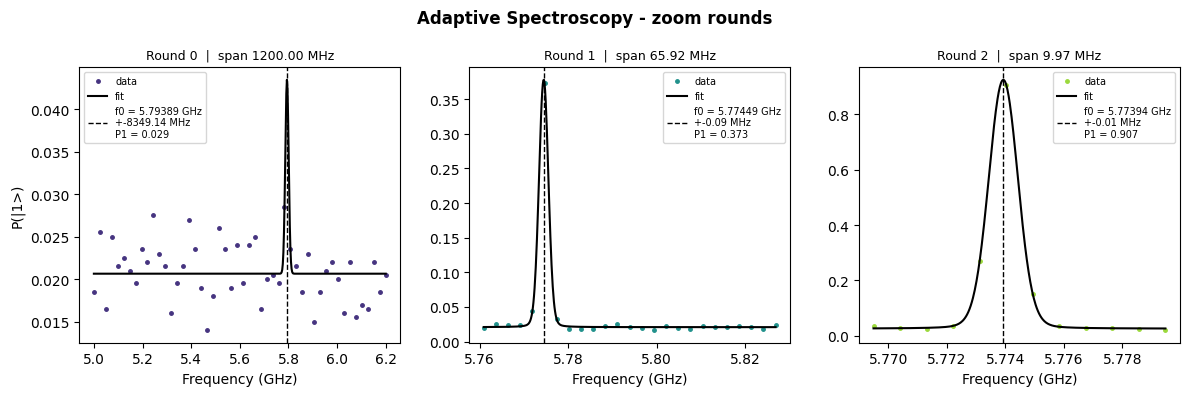

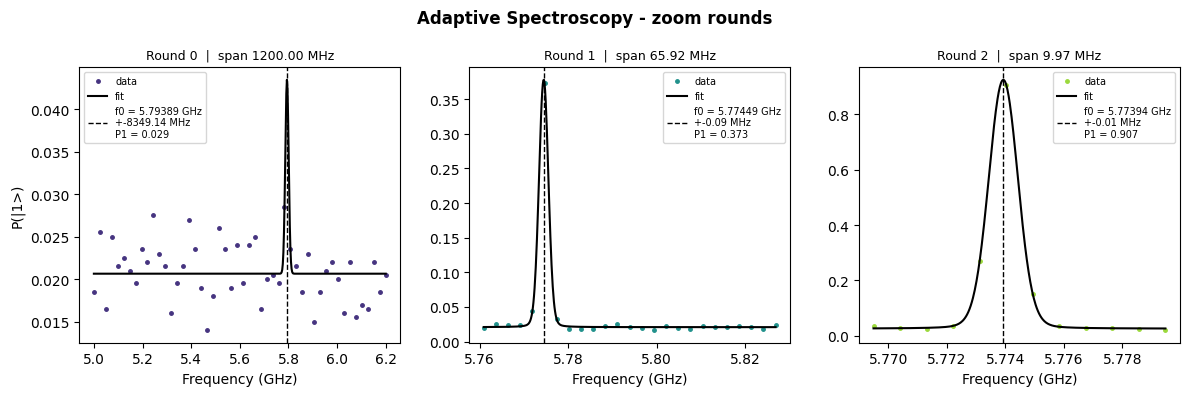

In [36]:
plot_adaptive_history(history)